
## Libraries


In [1]:

 !pip install mlxtend
 !pip install onnxmltools
 !pip install onnxruntime
 !pip install onnxscript


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import torch
import pandas as pd
import sklearn
import random

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [3]:
import matplotlib.pyplot as plt

from mlxtend.plotting import heatmap
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

## coefficient of determination
from sklearn.metrics import r2_score

In [4]:
import xgboost as xgb

In [5]:
import onnxruntime as rt
import onnxmltools
import onnxscript

from skl2onnx.common.data_types import FloatTensorType

In [141]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}")

True
1
0
NVIDIA GeForce RTX 4070 SUPER
cuda



## Parameters


In [327]:
## 0.001, 0.0001, 0.0003, 0.01, 0.03

batch_size    = 256
learning_rate = 0.001 ## 0.001
N_Epochs      = 200

epsilon = 0.0001


## Read data


In [286]:
path_data = 'C:\\Users\\Adrian\\Downloads\\housing.csv'

housing_raw_data = pd.read_csv( path_data, delimiter="," )
housing_raw_data.dropna(inplace = True)

In [287]:
housing_raw_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [288]:
headers_list = housing_raw_data.columns.values.tolist()
headers_list

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [289]:
headers_list2 = [ 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']


## Data Analysis

* Correlation matrix


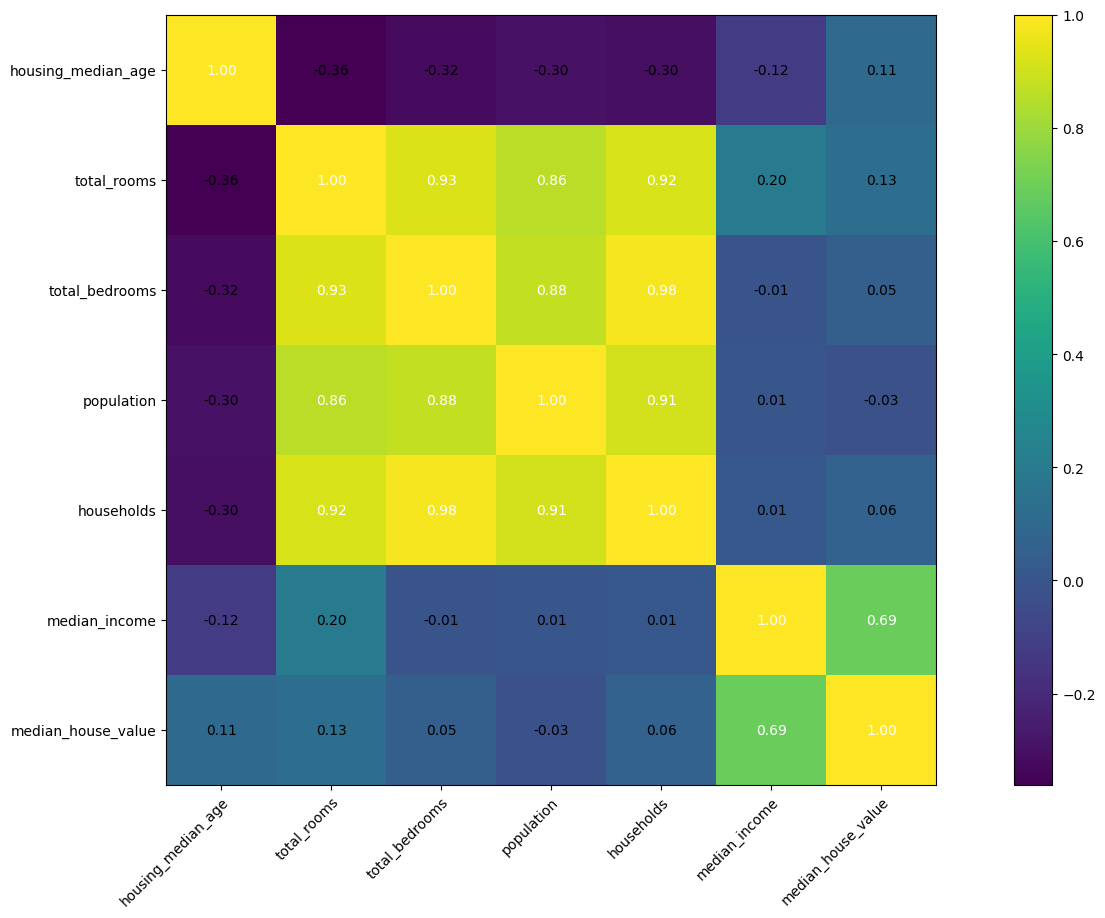

In [290]:
cm = np.corrcoef(   housing_raw_data[headers_list2].values.T   )
hm = heatmap(cm, row_names=headers_list2, column_names=headers_list2, figsize=(20,10))
plt.show()


## Process Data


In [338]:
## Convert Pandas to Numpy

housing_raw_data_np = housing_raw_data.to_numpy()

In [339]:
housing_raw_data_np

array([[-122.23, 37.88, 41.0, ..., 8.3252, 452600.0, 'NEAR BAY'],
       [-122.22, 37.86, 21.0, ..., 8.3014, 358500.0, 'NEAR BAY'],
       [-122.24, 37.85, 52.0, ..., 7.2574, 352100.0, 'NEAR BAY'],
       ...,
       [-121.22, 39.43, 17.0, ..., 1.7, 92300.0, 'INLAND'],
       [-121.32, 39.43, 18.0, ..., 1.8672, 84700.0, 'INLAND'],
       [-121.24, 39.37, 16.0, ..., 2.3886, 89400.0, 'INLAND']],
      shape=(20433, 10), dtype=object)

In [340]:
housing_raw_data_np.shape

(20433, 10)

In [341]:
X = housing_raw_data_np[:, 2:-2]
y = housing_raw_data_np[:, -2:-1]
y

array([[452600.0],
       [358500.0],
       [352100.0],
       ...,
       [92300.0],
       [84700.0],
       [89400.0]], shape=(20433, 1), dtype=object)

In [342]:
print(X.shape)
print(y.shape)

(20433, 6)
(20433, 1)


In [343]:
random_seed = int( random.random() * 100 )     ## 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

In [344]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
y_test.dtype

(16346, 6)
(4087, 6)
(16346, 1)
(4087, 1)


dtype('O')


## Fix in case float64 error


In [345]:
## fix data type
X_train = X_train.astype(  np.float32  )
X_test  = X_test.astype(   np.float32  )
y_train = y_train.astype(  np.float32  )
y_test  = y_test.astype(   np.float32  )

In [346]:
X_train_tr = torch.from_numpy(X_train)
X_test_tr  = torch.from_numpy(X_test)
y_train_tr = torch.from_numpy(y_train)
y_test_tr  = torch.from_numpy(y_test)


## Normalization

* Normalizartion
* Standardization (*)


In [347]:
x_means      = X_train_tr.mean(0, keepdim=True )
x_deviations = X_train_tr.std( 0, keepdim=True) + epsilon

In [348]:
y_mean = y_train_tr.mean(0, keepdim=True)
y_std  = y_train_tr.std(0, keepdim=True) #+ epsilon
print(y_mean)
print(y_std)

tensor([[206156.5469]])
tensor([[115063.8281]])


In [349]:
y_train_tr_scaled = (y_train_tr - y_mean) / y_std
y_test_tr_scaled  = (y_test_tr  - y_mean) / y_std

In [350]:
print(x_means)
print(x_deviations)

tensor([[  28.7093, 2642.2200,  538.0288, 1426.8447,  499.5566,    3.8669]])
tensor([[1.2605e+01, 2.2142e+03, 4.2345e+02, 1.1486e+03, 3.8428e+02, 1.8981e+00]])



## Create the DataLoader


In [351]:
train_ds = TensorDataset( X_train_tr, y_train_tr_scaled  )
train_dl = DataLoader( train_ds, batch_size, shuffle=True, pin_memory=True  )
train_dl


## Neural Network Architectures


In [362]:
## Deep Learning with 2 hidden layers
class DL_Net(nn.Module):
    ## init the class
    def __init__(self, x_means, x_deviations):
        super().__init__()

        self.register_buffer('x_means', x_means)
        self.register_buffer('x_deviations', x_deviations)

        self.linear1 = nn.Linear(6, 32)
        self.act1    = nn.ReLU()
        self.linear2 = nn.Linear(32, 16)
        self.act2    = nn.ReLU()
        self.linear3 = nn.Linear(16, 8)
        self.act3    = nn.ReLU()
        self.linear4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(0.25)

    ## perform inference
    def forward(self, x):

        x = (x - self.x_means) / self.x_deviations

        x = self.linear1(x)
        x = self.act1(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.linear3(x)
        x = self.act3(x)
        ##x = self.dropout(x)
        y_pred = self.linear4(x)

        ## return torch.round( y_pred )
        return y_pred

In [367]:
## Deep Learning with 2 hidden layers
class DL_Net(nn.Module):
    ## init the class
    def __init__(self, x_means, x_deviations):
        super().__init__()

        self.register_buffer('x_means', x_means)
        self.register_buffer('x_deviations', x_deviations)

        self.linear1 = nn.Linear(6, 32)
        self.bn1    = nn.BatchNorm1d(32)
        self.act1    = nn.ReLU()
        self.linear2 = nn.Linear(32, 16)
        self.bn2    = nn.BatchNorm1d(16)
        self.act2    = nn.ReLU()
        self.linear3 = nn.Linear(16, 8)
        self.bn3    = nn.BatchNorm1d(8)
        self.act3    = nn.ReLU()
        self.linear4 = nn.Linear(8, 1)
        self.dropout = nn.Dropout(0.25)

    ## perform inference
    def forward(self, x):

        x = (x - self.x_means) / self.x_deviations

        x = self.linear1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.linear2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.linear3(x)
        x = self.bn3(x)
        x = self.act3(x)
        ##x = self.dropout(x)
        y_pred = self.linear4(x)

        ## return torch.round( y_pred )
        return y_pred

## Training Loop

In [368]:
def training_loop( N_Epochs, model, loss_fn, opt  ):
    for epoch in range(N_Epochs):
        for xb, yb in train_dl:

            xb = xb.to(device, non_blocking=True)#.view(xb.size(0),-1)
            yb = yb.to(device, non_blocking=True)            

            y_pred = model(xb)
            loss   = loss_fn(y_pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

        if epoch % 10 == 0:
            print(epoch, "loss=", loss)

In [369]:
model = DL_Net(x_means, x_deviations)
model = model.to(device)
model.train()
opt     = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = F.mse_loss

training_loop(N_Epochs, model, loss_fn, opt)

0 loss= tensor(0.3773, device='cuda:0', grad_fn=<MseLossBackward0>)
10 loss= tensor(0.3136, device='cuda:0', grad_fn=<MseLossBackward0>)
20 loss= tensor(0.3453, device='cuda:0', grad_fn=<MseLossBackward0>)
30 loss= tensor(0.3871, device='cuda:0', grad_fn=<MseLossBackward0>)
40 loss= tensor(0.2527, device='cuda:0', grad_fn=<MseLossBackward0>)
50 loss= tensor(0.2804, device='cuda:0', grad_fn=<MseLossBackward0>)
60 loss= tensor(0.2657, device='cuda:0', grad_fn=<MseLossBackward0>)
70 loss= tensor(0.3156, device='cuda:0', grad_fn=<MseLossBackward0>)
80 loss= tensor(0.3026, device='cuda:0', grad_fn=<MseLossBackward0>)
90 loss= tensor(0.3030, device='cuda:0', grad_fn=<MseLossBackward0>)
100 loss= tensor(0.3880, device='cuda:0', grad_fn=<MseLossBackward0>)
110 loss= tensor(0.2632, device='cuda:0', grad_fn=<MseLossBackward0>)
120 loss= tensor(0.2667, device='cuda:0', grad_fn=<MseLossBackward0>)
130 loss= tensor(0.3302, device='cuda:0', grad_fn=<MseLossBackward0>)
140 loss= tensor(0.3474, device


## Evaluate Model


In [370]:
y_pred_test_scaled = model(X_test_tr.to(device))
y_pred_test = y_pred_test_scaled * y_std.to(device) + y_mean.to(device) #now in dollars
y_pred_test.shape

torch.Size([4087, 1])

In [371]:
print("Testing R**2: ", r2_score(y_test_tr.numpy(),  y_pred_test.detach().cpu().numpy()))
print(y_pred_test.shape)
print(y_test_tr.shape)
print(len(X_test_tr))

Testing R**2:  0.7043039798736572
torch.Size([4087, 1])
torch.Size([4087, 1])
4087


In [215]:
list_preds = []
list_reals = []

for i in range(len(X_test_tr)):
    print("************************************")
    print("pred, real")
    np_real =   y_test_tr[i].detach().cpu().numpy()
    np_pred = y_pred_test[i].detach().cpu().numpy()
    print(( np_pred  , np_real))
    list_preds.append(np_pred[0])
    list_reals.append(np_real[0])

************************************
pred, real
(array([175381.56], dtype=float32), array([207800.], dtype=float32))
************************************
pred, real
(array([70240.125], dtype=float32), array([49400.], dtype=float32))
************************************
pred, real
(array([240398.5], dtype=float32), array([251800.], dtype=float32))
************************************
pred, real
(array([102247.8], dtype=float32), array([75900.], dtype=float32))
************************************
pred, real
(array([95386.555], dtype=float32), array([64700.], dtype=float32))
************************************
pred, real
(array([61716.234], dtype=float32), array([45600.], dtype=float32))
************************************
pred, real
(array([126658.664], dtype=float32), array([78800.], dtype=float32))
************************************
pred, real
(array([83383.305], dtype=float32), array([59300.], dtype=float32))
************************************
pred, real
(array([154513.22], dty


## Deploy PyTorch Model


In [216]:
model.eval()

dummy_input = torch.randn(1, 6).to(device)
input_names  = ["input1"]
output_names = ["output1"]

torch.onnx.export(
        model,
        dummy_input,
        "DLnet_housingData.onnx",
        verbose=False,
        input_names = input_names,
        output_names = output_names
)

C:\Users\Adrian\anaconda3\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.11.0+cu130',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input1"<FLOAT,[1,6]>
            ),
            outputs=(
                %"output1"<FLOAT,[1,1]>
            ),
            initializers=(
                %"linear1.weight"<FLOAT,[32,6]>{TorchTensor(...)},
                %"linear1.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"linear2.weight"<FLOAT,[16,32]>{TorchTensor(...)},
                %"linear2.bias"<FLOAT,[16]>{TorchTensor(...)},
                %"linear3.weight"<FLOAT,[8,16]>{TorchTensor(...)},
                %"linear3.bias"<FLOAT,[8]>{TorchTensor<FLOAT,[8]>(Parameter containing: tensor([ 0.3946,  0.4171,  0.5730, -0.5684,  0.2927,  0.4791, -0.3330,  0.2454], device='cuda:0', requires_grad=Tru


## XGBoost


In [199]:
regressor = xgb.XGBRegressor(
        n_estimators=100,
        reg_lambda=1,
        gamma=0,
        max_depth=3
)

In [200]:
regressor.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [201]:
y_pred = regressor.predict(X_test)
print(y_pred.shape)
print(y_pred)
print(r2_score(y_test, y_pred))

(4087,)
[181398.28   56872.945 271263.22  ... 169653.6    72025.3   208868.12 ]
0.6773080229759216



## Deploy XGBoost Model

* ONNX and GitHub


In [202]:
initial_types = [(
          'float_input',
          FloatTensorType(  [None, 6 ]  )

)]

In [203]:
onnx_model = onnxmltools.convert_xgboost(regressor, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, 'xgboost_housing_ort.onnx')

In [204]:
sess = rt.InferenceSession('xgboost_housing_ort.onnx')

In [205]:
input_name = sess.get_inputs()[0].name
print(input_name)

float_input


In [206]:
label_name = sess.get_outputs()[0].name
print(label_name)

variable


In [207]:
pred_ort = sess.run([label_name], {input_name: X_test.astype(np.float32)})
pred_ort[0]

array([[181398.27],
       [ 56872.97],
       [271263.5 ],
       ...,
       [169653.6 ],
       [ 72025.3 ],
       [208868.08]], shape=(4087, 1), dtype=float32)